# Demand Forecasting Model

## Objective

The objective of this notebook is to build an AI model that predicts future product demand.

The predicted demand will later be used by the pricing engine and inventory optimization module.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("../data/raw/retail_store_inventory (1).csv")

In [3]:
df = pd.get_dummies(
    df,
    columns=[
        "Category",
        "Region",
        "Weather Condition",
        "Seasonality"
    ],
    drop_first=True
)

In [4]:
y = df["Demand Forecast"]

In [5]:
X = df.drop(
    columns=[
        "Demand Forecast",
        "Date",
        "Store ID",
        "Product ID"
    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

os.makedirs("models", exist_ok=True)

joblib.dump(
    model,
    "models/demand_forecast_model.pkl",
    compress=3
)

joblib.dump(
    X_train.columns.tolist(),
    "models/model_columns.pkl"
)

print("Model trained and saved successfully!")

Model trained and saved successfully!


In [8]:
predictions = model.predict(
    X_test
)

In [9]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 7.530212620426011
RMSE : 8.765537446864014
R² : 0.9935543412040129


In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,Units Sold,0.998197
0,Inventory Level,0.000384
2,Units Ordered,0.000345
6,Competitor Pricing,0.000286
3,Price,0.000279
4,Discount,0.000103
5,Holiday/Promotion,0.000038
16,Weather Condition_Sunny,0.000030
14,Weather Condition_Rainy,0.000030
12,Region_South,0.000029


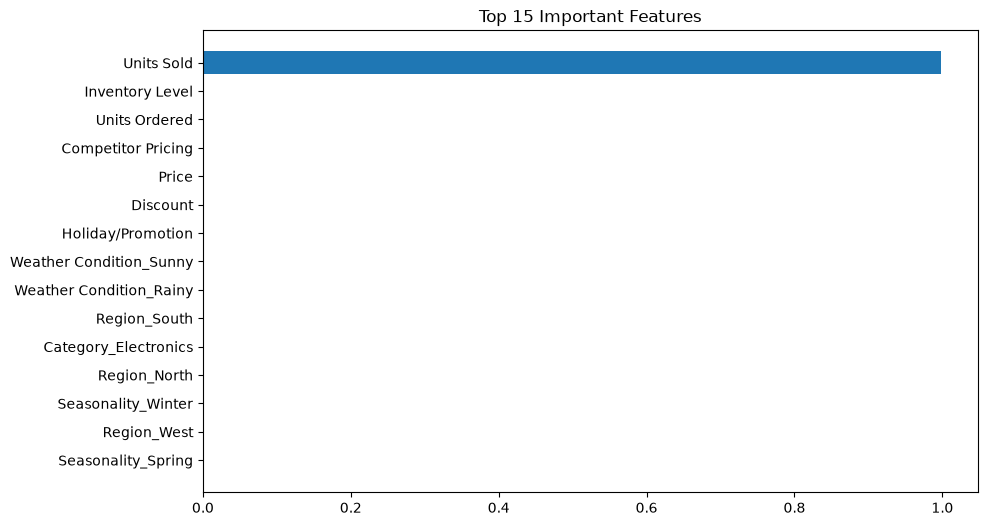

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [12]:
import joblib

joblib.dump(model, "../models/demand_forecast_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [13]:
joblib.dump(model, "../models/demand_forecast_model.pkl")

joblib.dump(
    X.columns.tolist(),
    "../models/model_columns.pkl"
)

print("Everything Saved Successfully!")

Everything Saved Successfully!
